In [ ]:
# Cell 1: Initialization and Setup

# Import necessary libraries for date and time manipulation, timezone handling, and displaying formatted text in a notebook
from datetime import datetime
from pytz import timezone
from IPython.display import display, Markdown

# Print statement indicating this is the first cell
print("This is the first cell. Initialization and setup are done below:")

# Set IST timezone
ist = timezone('Asia/Kolkata')

# Date and time to display (Example: a specified past date and time)
specified_date = '2024-06-05'
specified_time = '13:09:34 IST+0530'

# Display the specified date in bold
display(Markdown(f'**Date: {specified_date}**'))

# Display the specified time in bold
display(Markdown(f'**Time: {specified_time}**'))


This is the first cell. Initialization and setup are done below:


**Date: 2024-06-05**

**Time: 13:09:34 IST+0530**

# Movies_Recommendations by -> Association_rules

Hi Everyones This notebooks speaks about the implementation of association rules on movielens movies dataset.

If you like this work kernel, feel free to leave a comment or an upvote :)

* [INTRODUCTION TO ASSOCIATION RULES](#section-one)
    - [THEORETICAL PART](#subsection-one)
    - [PRACTICAL PART (coding)](#subsection-two)
* [ANALYSIS OF RESULTS](#section-two)
* [ENDNOTE & REFRENCES](#section-three)

<a id="section-one"></a>
# 1. INTRODUCTION TO ASSOCIATION RULES
Association rules analysis related algorithms, such as Apriori and FP-growth tree algorithms that can be defined as a developed techniques that been used for the transactional data type to compute how much association is between data values and thier relative combinations, like if a customer is 70% to buy a milk how likley a customer will also buy bread. Here will use two main types of algorithms are being used: The Apriori and the FP Growth, where data are structured as shown in **table 1**.

![image.png](attachment:image.png)

>- Table 1. *Transactional data example, adapted from Tan and etl (2013) Association Analysis: basic concepts and algorithms in Introduction to data mining*


It can be seen in the previous figure that ‘Bear’ from items columns have been seen in multiple rows, which means in cases such as  this item occur transaction this item occurs in most of rows which consider as support measure, but what does that means?.

<a id="subsection-one"></a>
# THEORETICAL PART

![](https://i.pinimg.com/originals/bd/5e/47/bd5e47075584914bcbe0f1fcff19c802.gif)


## 1.1. MAJOR COMPUTATION IN ASSOCIATION RULES
Association rules in general have the listed below major computaions in the dataset.

**Support:**
Is the percentage of the transaction that contains the items from the data set , which means how many times did the items occur in the dataset (Agrawal et al, 1993).

$ support  (A→C)=support (A∪C)$  ---> (range[0,1])

**Confidence:** The probability that items on left hand side and right hand side  of ruleset are occurring together, with a higher confidence will reflect a higher likelihood of the items that will be purchased together based on the given rule (Agrawal et al, 1993).

$confidence (A→C)=support (A→C) support(A)$  ---> (range [0,1])

**Lift:**
Probability of the all items set all occurring together in the rule. lift value more than 1 reflects that the presence of the item will increase with the presence of the other items and its occurrence in the same transaction, so the lift summarizes the strength of association rule as a link between the items of both sides (Brin et al, 1997).

$lift (A→C)=confidence (A→C) support(C)$ ---> (range[0,∞])

>- Note that left hand side and right hand side of the rules are identfied also as "antecedents" and "consequents".

## 1.2. STEPS TO COMPUTE ASSOCIATION RULES

>- 1. GENERATE FREQUENT ITEMSETS

>- 2. APPLY ASSOCIATION RULES ON GENERATED ITEMS SETS

### 1. GENERATE FREQUENT ITEMSETS

Two Algorithms (Apriori, and Fpgrowth) are going to be disccussed to generaten frequent itemsets which are going to be used later on to create association rules
### **Apriori Algorithm**
A pseudocode in **figure 2** implements the frequests itemsets generation of apriori algorithm. where Ck adopts a set of candidate k-itemsets, and the frequent set if itemsets are represented by Fk. apriori following the belows steps: (Tan and etl 2013)

1- The algorithm initially makes a single pass over the data set to determine the support of each item. Upon completion of this step, the set of all frequent 1-itemsets K.



2- Algorithm generate new candidate k-itemsets and prune unnecessary candidates that are guaranteed to be infrequent given the frequent (k−1) itemsets found in the previous iteration.


3- Algorithm makes an additional pass to count the support of the generated candidates. The subset function is used to determine all the candidate itemsets in Ck that are contained in each transaction t.


4- After counting support, the algorithm eliminates all candidate itemsets whose support counts are less than N  minimum support which is chosen by the user.


5- The algorithm terminates when there are no new frequent itemsets generated, ie Fk = ∅.


### **Fp-Growth Algorithm**
The algorithm does not create candidate sets in the same fashion as apriori in terms of multiple passes over the entire dataset. since it needs only two scans over the dataset to extract frequent itemsets from it, which makes it faster  and less expensive than apriori.

1- The algorithm scans the whole dataset one time to calculate each item support cout. and ignore the infrequent items, and sort the generated item set in a descending order.

2- Algorithm construct the Fp-tree by making a second pass over the data set. After reading the first transaction the first transaction is created  as a node between those items where a path is generated to encode this relation, and every node along the path has a frequency count of 1.

3- This process continues until  all the generated transactions are mapped onto their relative path that have been constructed by the Fp-Tree.

![Screen%20Shot%202020-06-03%20at%205.40.35%20PM.png](attachment:Screen%20Shot%202020-06-03%20at%205.40.35%20PM.png)

>- Figure 3.  *Fp-Growth algorithm generation, adapted from Tan and etl (2013) Association Analysis: basic concepts and algorithms in Introduction to data mining.*


## Drawbacks in association rules
Due to the iterative process of rules generation in association rules mining where every item in the dataset is compared against each item and so on, the increase in items and transaction can make the computation very expensive, (Tan and etl 2013) listed some limitations that can be solved by decrease the dimensionality in datasets.and reduce the number of item sets in terms of columns and rows that need to be computed, that can be reduced by setting threshold to compute items sets that pases the threshold only.


<a id="subsection-two"></a>
# 2. PRACTICAL PART

<img src="https://media.giphy.com/media/heIX5HfWgEYlW/giphy.gif">



## 2.1. DATASET (ml-latest-small.zip)


<p><span style="color:red"> <em>for the demonstration purpose we selected a smaller version of dataset to implement the tutorial.
</em></span></p>

This dataset (ml-latest) describes 5-star rating and free-text tagging activity from MovieLens, a movie recommendation service. It contains 27753444 ratings and 1108997 tag applications across 58098 movies. These data were created by 283228 users between January 09, 1995 and September 26, 2018. This dataset was generated on September 26, 2018.

More information about the data and description can be found in the link: http://files.grouplens.org/datasets/movielens/ml-latest-README.html

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [ ]:
import requests, zipfile, io
zipfile.ZipFile(io.BytesIO(requests.get('http://files.grouplens.org/datasets/movielens/ml-latest-small.zip').content)).extractall()

In [ ]:
ls -a ml-latest-small

./  ../  links.csv  movies.csv  ratings.csv  README.txt  tags.csv


## 2.2. SELECTED DATA

Here we can see from the directory of the uncompressed file that we have a total of 5 data set, we are going to select and observed which one that contain needed data for the implementation of association rules. which should look similar to **Table. 1**.

In [ ]:
data_movies = pd.read_csv('ml-latest-small/movies.csv')
data_tages = pd.read_csv('ml-latest-small/tags.csv')
data_ratings = pd.read_csv('ml-latest-small/ratings.csv')

### Movies Data

This is the only dataset that contains the titile of the movies and each movie unique key.

In [ ]:
data_movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
data_movies.movieId.value_counts(),print('Number of duplicated unique ids are: ',data_movies.movieId.duplicated().sum())

Number of duplicated unique ids are:  0


(movieId
 1         1
 53322     1
 53129     1
 53138     1
 53140     1
          ..
 4390      1
 4392      1
 4393      1
 4394      1
 193609    1
 Name: count, Length: 9742, dtype: int64,
 None)

### Movies tages Data
This dataset contain the added tags to the movie plus the userid which is valuable to be considered as an index to each transaction, on the other hand the dataset has less movie ids than the rating dataset which made us select it instead.


In [ ]:
data_tages

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200
...,...,...,...,...
3678,606,7382,for katie,1171234019
3679,606,7936,austere,1173392334
3680,610,3265,gun fu,1493843984
3681,610,3265,heroic bloodshed,1493843978


In [ ]:
data_tages.movieId.value_counts()

,count
movieId,
296,181
2959,54
924,41
293,35
7361,34
...,...
3307,1
3310,1
3317,1


### Movies Rating Data

Movies rating data contain more that 9k movies ids which can be usefull to be merged with the movies title dataset.


In [ ]:
data_ratings

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [ ]:
data_ratings.movieId.value_counts()

,count
movieId,
356,329
318,317
296,307
593,279
2571,278
...,...
86279,1
86922,1
5962,1


## 2.3. MERGING DATASETS

in this case inner join is selected since we need the data only when both movieId labels are existed on both datasets.

more details about merging can be found in pandas documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/merging.html

In [ ]:
merge = data_movies.merge(data_tages,on = 'movieId',how = 'inner')

In [ ]:
merge

,movieId,title,genres,userId,tag,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,336,pixar,1139045764
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,474,pixar,1137206825
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,567,fun,1525286013
3,2,Jumanji (1995),Adventure|Children|Fantasy,62,fantasy,1528843929
4,2,Jumanji (1995),Adventure|Children|Fantasy,62,magic board game,1528843932
...,...,...,...,...,...,...
3678,187595,Solo: A Star Wars Story (2018),Action|Adventure|Children|Sci-Fi,62,star wars,1528934552
3679,193565,Gintama: The Movie (2010),Action|Animation|Comedy|Sci-Fi,184,anime,1537098582
3680,193565,Gintama: The Movie (2010),Action|Animation|Comedy|Sci-Fi,184,comedy,1537098587
3681,193565,Gintama: The Movie (2010),Action|Animation|Comedy|Sci-Fi,184,gintama,1537098603


Dropiong unneeded columns.

In [ ]:
merge.drop(columns=['tag','timestamp','genres'],inplace=True)

In [ ]:
merge

,movieId,title,userId
0,1,Toy Story (1995),336
1,1,Toy Story (1995),474
2,1,Toy Story (1995),567
3,2,Jumanji (1995),62
4,2,Jumanji (1995),62
...,...,...,...
3678,187595,Solo: A Star Wars Story (2018),62
3679,193565,Gintama: The Movie (2010),184
3680,193565,Gintama: The Movie (2010),184
3681,193565,Gintama: The Movie (2010),184


Since we are going to merge. lets observe how many users we have.

In [ ]:
len(merge.userId.unique())

58

Here we preprocess the dataset to create a transactional list were every row represent a user and his selected movies, which is similar to table. 1.

In [ ]:
merge_list = merge.groupby(by = ["userId"])["title"].apply(list).reset_index()
merge_list.head()

,userId,title
0,2,"[Step Brothers (2008), Step Brothers (2008), S..."
1,7,"[Departed, The (2006)]"
2,18,"[Carlito's Way (1993), Carlito's Way (1993), C..."
3,21,"[My Best Friend's Wedding (1997), My Best Frie..."
4,49,"[Interstellar (2014), Interstellar (2014), Int..."


sample of the list

In [ ]:
merge_list = merge_list["title"].tolist()
merge_list[0:3]

[['Step Brothers (2008)',
  'Step Brothers (2008)',
  'Step Brothers (2008)',
  'Warrior (2011)',
  'Warrior (2011)',
  'Warrior (2011)',
  'Wolf of Wall Street, The (2013)',
  'Wolf of Wall Street, The (2013)',
  'Wolf of Wall Street, The (2013)'],
 ['Departed, The (2006)'],
 ["Carlito's Way (1993)",
  "Carlito's Way (1993)",
  "Carlito's Way (1993)",
  'Godfather: Part II, The (1974)',
  'Godfather: Part II, The (1974)',
  'Pianist, The (2002)',
  'Pianist, The (2002)',
  'Lucky Number Slevin (2006)',
  'Fracture (2007)',
  'Fracture (2007)',
  'Fracture (2007)',
  'Upside Down: The Creation Records Story (2010)',
  'Upside Down: The Creation Records Story (2010)',
  'Upside Down: The Creation Records Story (2010)',
  'Just Eat It: A Food Waste Story (2014)',
  'Just Eat It: A Food Waste Story (2014)']]

To validate the created list per userId we can see it is the same as the code below.
```python
len(merge.userId.unique())```

In [ ]:
len(merge_list)

58

## 2.4. DATA TRANSFORMATION

Here data is transfered as a binary input to be accepted by the algorithm, serveral methods are avalible in several packages such as:

---


```python
pandas.get_dummies```


```from mlxtend.preprocessing import TransactionEncoder```




```sklearn.preprocessing.OneHotEncoder```

In [ ]:
from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(merge_list).transform(merge_list)
df = pd.DataFrame(te_ary, columns=te.columns_)

In [ ]:
df.head()

,(500) Days of Summer (2009),...And Justice for All (1979),10 Cloverfield Lane (2016),10 Things I Hate About You (1999),101 Dalmatians (1996),101 Dalmatians (One Hundred and One Dalmatians) (1961),"11'09""01 - September 11 (2002)",12 Angry Men (1957),127 Hours (2010),13 Going on 30 (2004),2001: A Space Odyssey (1968),21 Grams (2003),25th Hour (2002),28 Days Later (2002),"39 Steps, The (1935)",3:10 to Yuma (2007),"40-Year-Old Virgin, The (2005)","400 Blows, The (Les quatre cents coups) (1959)",42 Up (1998),84 Charing Cross Road (1987),8MM (1999),A Million Ways to Die in the West (2014),A Pigeon Sat on a Branch Reflecting on Existence (2014),A Story of Children and Film (2013),A.I. Artificial Intelligence (2001),About a Boy (2002),"Accused, The (1988)",Adam's Rib (1949),Addams Family Values (1993),"Addams Family, The (1991)","Adventures of Priscilla, Queen of the Desert, The (1994)","Adventures of Robin Hood, The (1938)","African Queen, The (1951)",After the Thin Man (1936),"Age of Innocence, The (1993)",Air Force One (1997),Airheads (1994),Airplane! (1980),Akira (1988),Aladdin (1992),Alfie (1966),Alice Adams (1935),Alice Doesn't Live Here Anymore (1974),Alice in Wonderland (1951),Alien (1979),Aliens (1986),Alive (1993),All About Eve (1950),All the King's Men (1949),All the President's Men (1976),All the Real Girls (2003),Almost Famous (2000),Amadeus (1984),"Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001)",Amen. (2002),America's Sweethearts (2001),American Gangster (2007),American History X (1998),American Movie (1999),American Pie (1999),"American President, The (1995)",American Splendor (2003),"American in Paris, An (1951)","Americanization of Emily, The (1964)",Anastasia (1956),Anatomy of a Murder (1959),Anchorman 2: The Legend Continues (2013),Anchorman: The Legend of Ron Burgundy (2004),And Then There Were None (1945),And the Band Played On (1993),"Andalusian Dog, An (Chien andalou, Un) (1929)",Angel's Egg (Tenshi no tamago) (1985),Angie (1994),Animal House (1978),"Animatrix, The (2003)",Anna Karenina (1997),Anne Frank Remembered (1995),Anne of the Thousand Days (1969),Annie Hall (1977),Another Thin Man (1939),"Apartment, The (1960)",Apocalypse Now (1979),Apollo 13 (1995),Arachnophobia (1990),Argo (2012),"Aristocats, The (1970)",Armageddon (1998),Around the World in 80 Days (1956),Arrival (2016),"Arrival, The (1996)",Arsenic and Old Lace (1944),"Astronaut's Wife, The (1999)",Au Hasard Balthazar (1966),Auntie Mame (1958),Avalon (1990),Avatar (2009),"Avengers, The (2012)",Avengers: Infinity War - Part I (2018),"Aviator, The (2004)","Awful Truth, The (1937)","Babadook, The (2014)",Babe (1995),Babel (2006),Babette's Feast (Babettes gæstebud) (1987),Babylon 5: In the Beginning (1998),"Bachelor and the Bobby-Soxer, The (1947)",Back to the Future (1985),Back to the Future Part II (1989),Bad Day at Black Rock (1955),"Bad News Bears, The (1976)","Bad Seed, The (1956)","Bad and the Beautiful, The (1952)","Ballad of Jack and Rose, The (2005)","Bank Job, The (2008)",Barton Fink (1991),"Basketball Diaries, The (1995)",Batman (1989),Batman Forever (1995),Batman Returns (1992),Batman v Superman: Dawn of Justice (2016),Battle Royale (Batoru rowaiaru) (2000),"Battle of Algiers, The (La battaglia di Algeri) (1966)",Beasts of No Nation (2015),Beasts of the Southern Wild (2012),Beat the Devil (1953),"Beautiful Mind, A (2001)",Beauty and the Beast (1991),Before Sunrise (1995),Before Sunset (2004),Begotten (1990),Being Julia (2004),Being There (1979),"Believer, The (2001)",Bend It Like Beckham (2002),Benny & Joon (1993),Best in Show (2000),Better Luck Tomorrow (2002),Better Off Dead... (1985),Beyond Silence (Jenseits der Stille) (1996),Big (1988),Big Business (1988),Big Daddy (1999),Big Eyes (2014),Big Fish (2003),Big Hero 6 (2014),"Big Kahuna, The (2000)","Big Lebowski, The (1998)",Big Night (1996),"Big Short, The (2015)","Big Sleep, The (1946)",Big Top Pee-Wee (1988),Bill & Ted's Bogus Journey (1991),Bill & Ted's Excellent Adventure (1989

In [ ]:
df.shape

(58, 1572)

## 2.5. GENERATING FREQUENT ITEMSETS
This section implement the use of the itemsets generation according to the selected parameters  ``` min_support=0.01,max_len=2``` as a threshold to paneltize the algorithm of using a huge memory size of the machine (1% support value, and maxixmum length of two items in each row is selected) as well.

- **NOTE:** Note that the results frequent items are python frozensets, which can not be selected by pandas methods such as ```pd.loc[]```.


### APRIORI

In [ ]:
from mlxtend.frequent_patterns import apriori
%time
apriori_frequent_itemsets = apriori(df, min_support=0.01,use_colnames=True,max_len=2)

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 5.96 µs


In [ ]:
apriori_frequent_itemsets['itemsets'].apply(lambda x: len(x)).value_counts()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,count
itemsets,
2,774986
1,1572


### Fpgrowth

In [ ]:
from mlxtend.frequent_patterns import fpgrowth
%time
fpgrowth_frequent_itemsets = fpgrowth(df, min_support=0.01, use_colnames=True,max_len=2)
fpgrowth_frequent_itemsets.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


CPU times: user 2 µs, sys: 1 µs, total: 3 µs
Wall time: 5.01 µs


,support,itemsets
0,0.051724,(Step Brothers (2008))
1,0.034483,"(Wolf of Wall Street, The (2013))"
2,0.017241,(Warrior (2011))
3,0.051724,"(Departed, The (2006))"
4,0.034483,"(Godfather: Part II, The (1974))"


In [ ]:
fpgrowth_frequent_itemsets['itemsets'].apply(lambda x: len(x)).value_counts()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,count
itemsets,
2,774986
1,1572


Sounds intresting that fpgrowth passed apriori in small dataset, on the other hand the number of generated item sets are the same in both algorithms.

<a id="section-two"></a>

## 2.6. ANAYSIS TO THE RESULTS

Lets create new feature that can be used for furthur analysis.

In [ ]:
fpgrowth_frequent_itemsets['length'] = fpgrowth_frequent_itemsets['itemsets'].apply(lambda x: len(x))
fpgrowth_frequent_itemsets

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,support,itemsets,length
0,0.051724,(Step Brothers (2008)),1
1,0.034483,"(Wolf of Wall Street, The (2013))",1
2,0.017241,(Warrior (2011)),1
3,0.051724,"(Departed, The (2006))",1
4,0.034483,"(Godfather: Part II, The (1974))",1
...,...,...,...
776553,0.017241,(Night of the Shooting Stars (Notte di San Lor...,2
776554,0.017241,(Night of the Shooting Stars (Notte di San Lor...,2
776555,0.017241,"(Gladiator (2000), Night of the Shooting Stars...",2
776556,0.017241,"(I'm Not Scared (Io non ho paura) (2003), Nigh...",2


Apply some basic analysis that can used to generate some intresting insights

* filter by columns based on numerial conditions

In [ ]:
fpgrowth_frequent_itemsets[(fpgrowth_frequent_itemsets['length'] > 1)
                          & (fpgrowth_frequent_itemsets['support'] > 0.06)].head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,support,itemsets,length
5225,0.068966,"(Memento (2000), Eternal Sunshine of the Spotl...",2
5392,0.086207,"(Donnie Darko (2001), Eternal Sunshine of the ...",2
5394,0.068966,"(Donnie Darko (2001), Memento (2000))",2
7011,0.068966,"(Donnie Darko (2001), Blade Runner (1982))",2
7012,0.068966,"(Memento (2000), Blade Runner (1982))",2


* Filtering by itemset length

In [ ]:
fpgrowth_frequent_itemsets[(fpgrowth_frequent_itemsets['length'] != 1)]


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,support,itemsets,length
1572,0.034483,"(Anchorman: The Legend of Ron Burgundy (2004),...",2
1573,0.017241,"(Step Brothers (2008), Corpse Bride (2005))",2
1574,0.017241,"(City of God (Cidade de Deus) (2002), Step Bro...",2
1575,0.017241,"(Departed, The (2006), Step Brothers (2008))",2
1576,0.017241,"(Terminator 2: Judgment Day (1991), Step Broth...",2
...,...,...,...
776553,0.017241,(Night of the Shooting Stars (Notte di San Lor...,2
776554,0.017241,(Night of the Shooting Stars (Notte di San Lor...,2
776555,0.017241,"(Gladiator (2000), Night of the Shooting Stars...",2
776556,0.017241,"(I'm Not Scared (Io non ho paura) (2003), Nigh...",2


* Generate insights by filtering values based on thier combnations and occurances in all dataset.

In [ ]:
fpgrowth_frequent_itemsets[fpgrowth_frequent_itemsets['itemsets'] == {'Step Brothers (2008)', 'Corpse Bride (2005)'}]

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,support,itemsets,length
1573,0.017241,"(Step Brothers (2008), Corpse Bride (2005))",2


* And we can search also by all itemset in all frequent itemsets.

In [ ]:
fpgrowth_frequent_itemsets[fpgrowth_frequent_itemsets['itemsets'].apply(lambda x: 'Step Brothers (2008)' in str(x))]

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,support,itemsets,length
0,0.051724,(Step Brothers (2008)),1
1572,0.034483,"(Anchorman: The Legend of Ron Burgundy (2004),...",2
1573,0.017241,"(Step Brothers (2008), Corpse Bride (2005))",2
1574,0.017241,"(City of God (Cidade de Deus) (2002), Step Bro...",2
1575,0.017241,"(Departed, The (2006), Step Brothers (2008))",2
...,...,...,...
10131,0.017241,"(Prisoners (2013), Step Brothers (2008))",2
10201,0.017241,"(Old School (2003), Step Brothers (2008))",2
10272,0.017241,"(Now You See Me (2013), Step Brothers (2008))",2
10344,0.017241,"(Step Brothers (2008), Night at the Roxbury, A...",2


* We can observe more the relation between support and length using correlation and hexbin plot. we can see an increse of rows that consist in more than one itemset. we can observe more insights if we had a multiple items in terms of items length instead of two only as a maximum in this example.

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


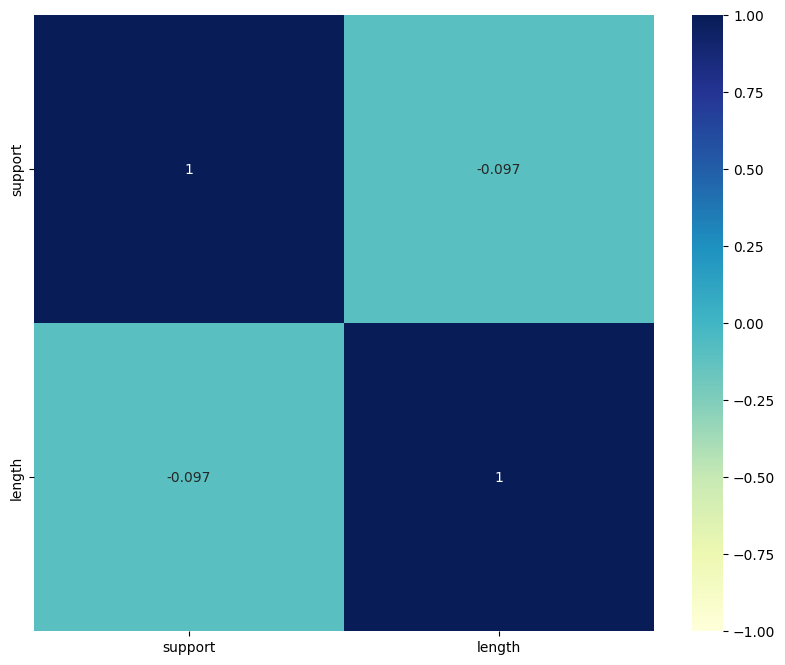

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns from the DataFrame
numerical_columns = fpgrowth_frequent_itemsets.select_dtypes(include=[float, int])

# Calculate the correlation matrix
corr_matrix = numerical_columns.corr(method='spearman')

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data=corr_matrix, annot=True, vmin=-1, vmax=1, center=0, cmap='YlGnBu')
plt.show()


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


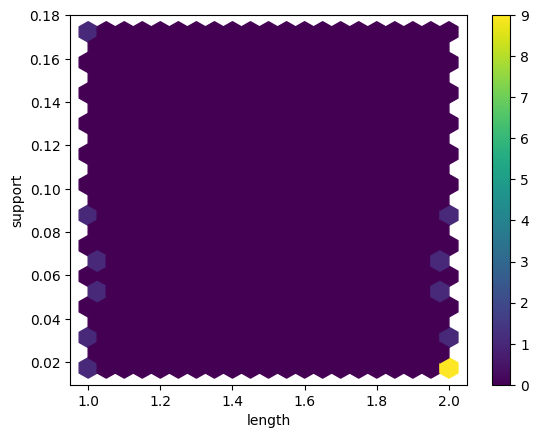

In [ ]:
fpgrowth_frequent_itemsets.plot.hexbin(x='length',y='support',cmap='viridis',gridsize=20,sharex=False,bins=10);

## 2.6. ASSOCIATION RULES

mlxtend module compute additional measures such as:

from mlxtend documentation:

  - $leverage(A->C) = support(A->C) - support(A)*support(C)$
--->range: [-1, 1]

  - $conviction = [1 - support(C)] / [1 - confidence(A->C)]$
--->range: [0, inf]


Leverage computes the difference between the observed frequency of A and C appearing together and the frequency that would be expected if A and C were independent. An leverage value of 0 indicates independence.

A high conviction value means that the consequent is highly depending on the antecedent. For instance, in the case of a perfect confidence score, the denominator becomes 0 (due to 1 - 1) for which the conviction score is defined as 'inf'. Similar to lift, if items are independent, the conviction is 1.

- **Here we are selecting the measure 'Lift' as a score evaluation method**

In [ ]:
%%time
from mlxtend.frequent_patterns import association_rules
rules = association_rules(fpgrowth_frequent_itemsets,metric="lift",min_threshold=0.01)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


CPU times: user 14.3 s, sys: 854 ms, total: 15.2 s
Wall time: 15.2 s


In [ ]:
rules

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(Anchorman: The Legend of Ron Burgundy (2004)),(Step Brothers (2008)),0.068966,0.051724,0.034483,0.500000,9.666667,0.030916,1.896552,0.962963
1,(Step Brothers (2008)),(Anchorman: The Legend of Ron Burgundy (2004)),0.051724,0.068966,0.034483,0.666667,9.666667,0.030916,2.793103,0.945455
2,(Step Brothers (2008)),(Corpse Bride (2005)),0.051724,0.051724,0.017241,0.333333,6.444444,0.014566,1.422414,0.890909
3,(Corpse Bride (2005)),(Step Brothers (2008)),0.051724,0.051724,0.017241,0.333333,6.444444,0.014566,1.422414,0.890909
4,(City of God (Cidade de Deus) (2002)),(Step Brothers (2008)),0.051724,0.051724,0.017241,0.333333,6.444444,0.014566,1.422414,0.890909
...,...,...,...,...,...,...,...,...,...,...
1549967,(Night of the Shooting Stars (Notte di San Lor...,(Gladiator (2000)),0.017241,0.034483,0.017241,1.000000,29.000000,0.016647,inf,0.982456
1549968,(I'm Not Scared (Io non ho paura) (2003)),(Night of the Shooting Stars (Notte di San Lor...,0.034483,0.017241,0.017241,0.500000,29.000000,0.016647,1.965517,1.000000
1549969,(Night of the Shooting Stars (Notte di San Lor...,(I'm Not Scared (Io non ho paura) (2003)),0.017241,0.034483,0.017241,1.000000,29.000000,0.016647,inf,0.982456
1549970,(John Wick: Chapter Two (2017)),(Hard-Boiled (Lat sau san taam) (1992)),0.034483,0.017241,0.017241,0.500000,29.000000,0.016647,1.965517,1.000000


In [ ]:
rules[rules["antecedents"].apply(lambda x: "Inception (2010)" in str(x))].sort_values(ascending=False,by='lift')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
1534852,(Inception (2010)),(Gentlemen Broncos (2009)),0.068966,0.017241,0.017241,0.25,14.500000,0.016052,1.310345,1.000000
1538020,(Inception (2010)),(Rare Exports: A Christmas Tale (Rare Exports)...,0.068966,0.017241,0.017241,0.25,14.500000,0.016052,1.310345,1.000000
1538287,(Inception (2010)),((500) Days of Summer (2009)),0.068966,0.017241,0.017241,0.25,14.500000,0.016052,1.310345,1.000000
1538320,(Inception (2010)),"(Avengers, The (2012))",0.068966,0.034483,0.034483,0.50,14.500000,0.032105,1.931034,1.000000
1538360,(Inception (2010)),(Captain Phillips (2013)),0.068966,0.034483,0.034483,0.50,14.500000,0.032105,1.931034,1.000000
...,...,...,...,...,...,...,...,...,...,...
36,(Inception (2010)),(Step Brothers (2008)),0.068966,0.051724,0.017241,0.25,4.833333,0.013674,1.264368,0.851852
6182,(Inception (2010)),(Pulp Fiction (1994)),0.068966,0.068966,0.017241,0.25,3.625000,0.012485,1.241379,0.777778
10874,(Inception (2010)),(Fight Club (1999)),0.068966,0.068966,0.017241,0.25,3.625000,0.012485,1.241379,0.777778
461,(Inception (2010)),(Anchorman: The Legend of Ron Burgundy (2004)),0.068966,0.068966,0.017241,0.25,3.625000,0.012485,1.241379,0.777778


A less messy way to group the top 10 related movies to the selected one.

We can see here the selected movie inception has top values of lift on related movie due to the same director in them (Dunkirk)

In [ ]:
rules[rules["antecedents"].apply(lambda x: "Inception (2010)" in str(x))].groupby(
    ['antecedents', 'consequents'])[['lift']].max().sort_values(ascending=False,by='lift').head(10)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


lift
antecedents        consequents                                             
(Inception (2010)) (Gentlemen Broncos (2009))                          14.5
                   (Life Aquatic with Steve Zissou, The (2004))        14.5
                   (400 Blows, The (Les quatre cents coups) (1959))    14.5
                   (A Pigeon Sat on a Branch Reflecting on Existen...  14.5
                   (Arrival (2016))                                    14.5
                   (Andalusian Dog, An (Chien andalou, Un) (1929))     14.5
                   (Angel's Egg (Tenshi no tamago) (1985))             14.5
                   (Illusionist, The (2006))                           14.5
                   (Dunkirk (2017))                                    14.5
                   (Don't Breathe (2016))                              14.5

An increasing value of lift is relatively associated with the increase of other measures such as confidence, lets observe top 10 movies that are relativley confidenent to be watched with the selected movie 'Inception'.

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


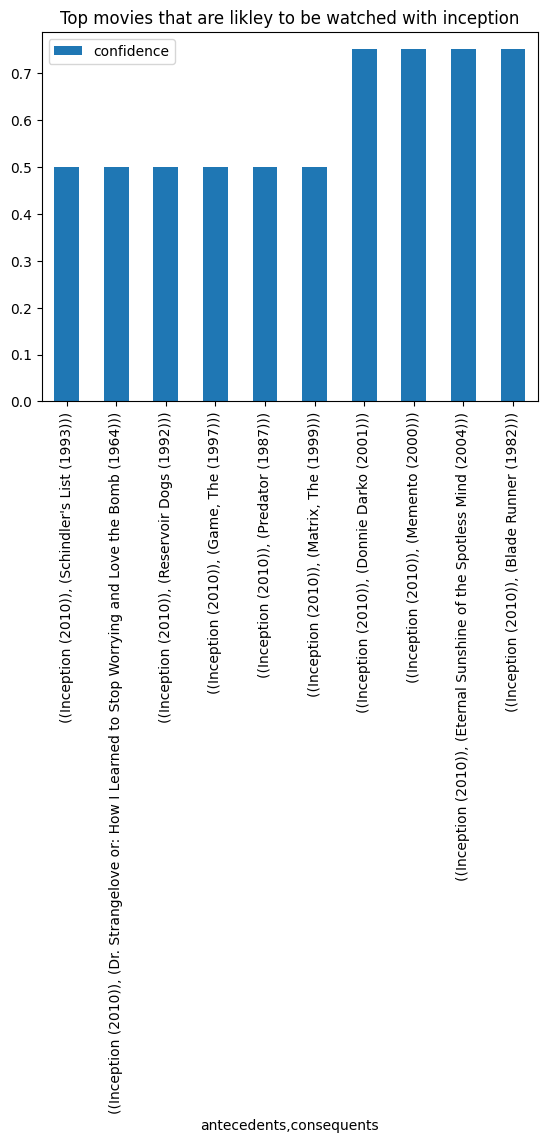

In [ ]:
rules[rules["antecedents"].apply(lambda x: "Inception (2010)" in str(x))].groupby(
    ['antecedents', 'consequents'])[['confidence']].max().sort_values(ascending=False,
                                                                      by='confidence').head(10).plot(kind='bar').invert_xaxis()
plt.title('Top movies that are likley to be watched with inception');

## 2.7. Visulizing Association rules (Networkx)

One intresting way to view such data can be used by a network analysis type of plots which can be used to visulize the relation between each feature and it is crosspounding feature in same dataset. Here we used **Networkx** modules which can be implemented to selected top 100 strongest relation. netwrokx modules has many layouts can be plot which depends on nodes, here we selected ``'planar_layout'`` as it can present the huge selection of data points clearly and beatifully.

>- Note: we added a lambda function to convert the forzenset to a string, to eliminate printing frozenset with each created node.

In [ ]:
rules['antecedents'] = rules.antecedents.apply(lambda x: next(iter(x)))
rules['consequents'] = rules.consequents.apply(lambda x: next(iter(x)))

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


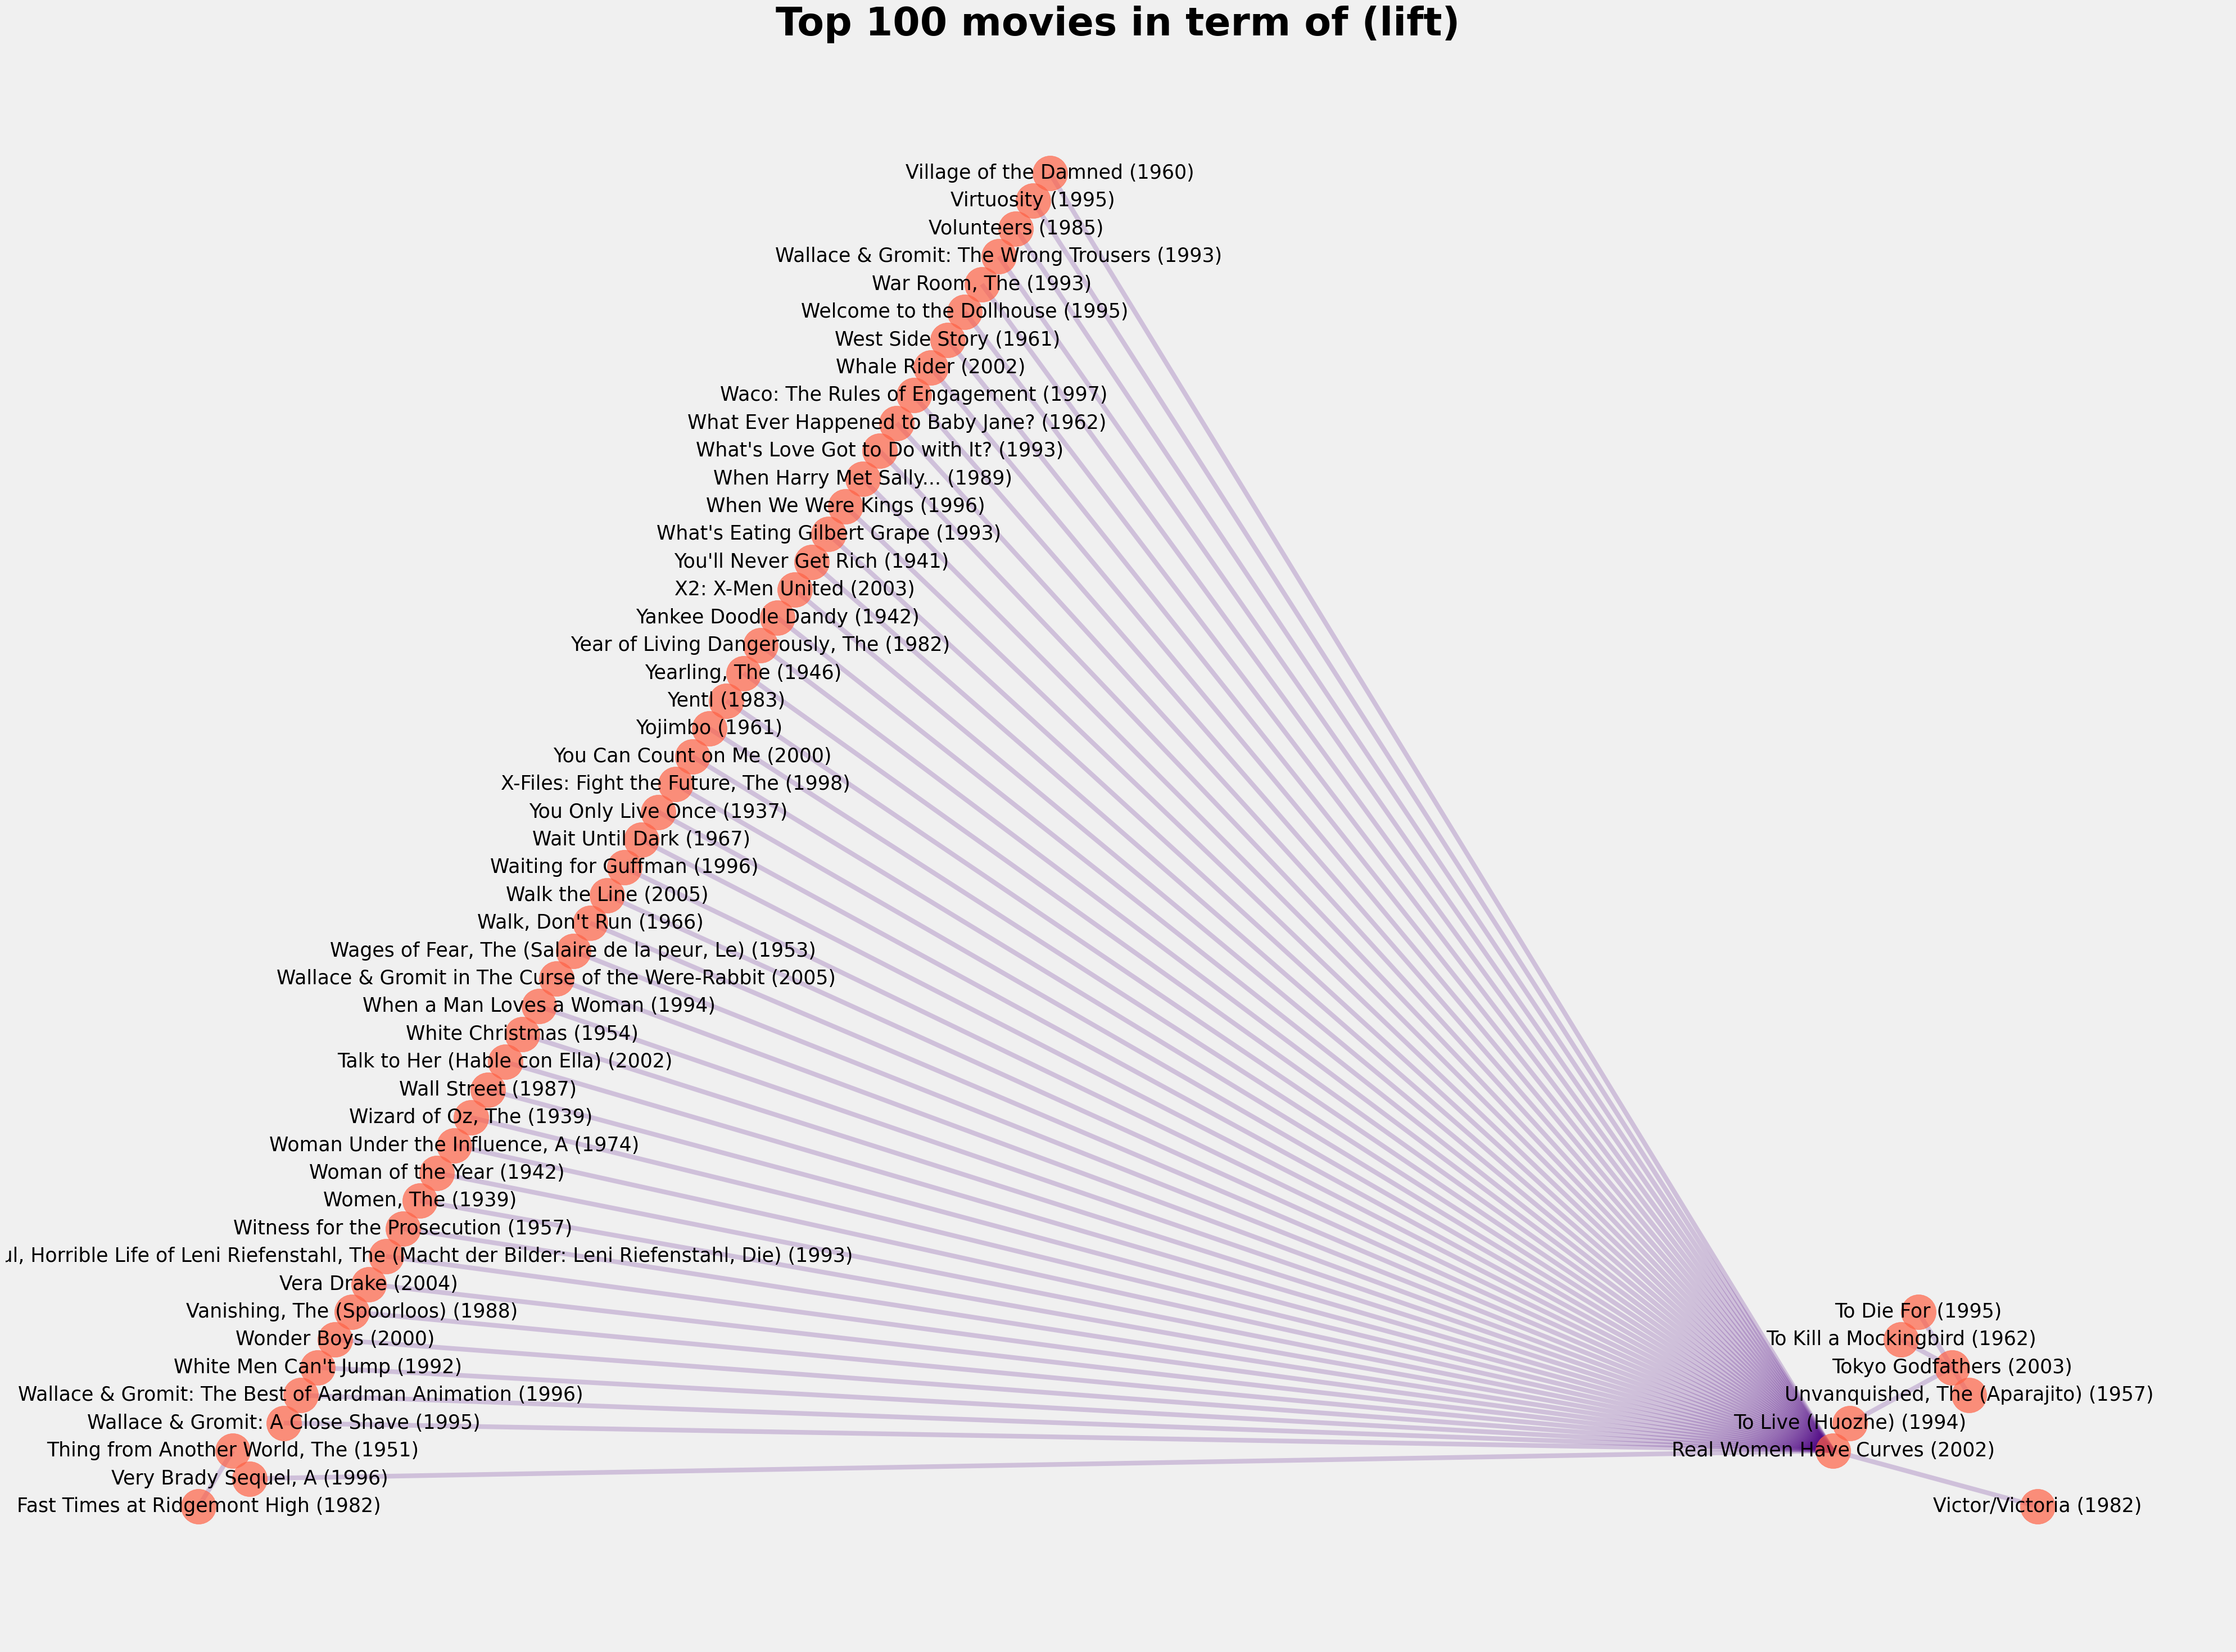

In [ ]:
import networkx as nx
import warnings
import matplotlib.pyplot as plt

# Suppress warnings
warnings.filterwarnings('ignore')

# Set style for the plot
plt.style.use('fivethirtyeight')

# Create a graph from the top 100 edges sorted by 'lift'
edges = nx.from_pandas_edgelist(rules.sort_values(ascending=False, by='lift').head(100),
                                source='antecedents', target='consequents', edge_attr=None)

# Create a plot with specified size and title
plt.subplots(figsize=(40, 30))
plt.suptitle('Top 100 movies in term of (lift)', fontsize=50, fontweight='bold')

# Generate the layout for the graph
pos = nx.planar_layout(edges)

# Draw the nodes, edges, and labels
nx.draw_networkx_nodes(edges, pos, node_size=2000, alpha=0.7, node_color='tomato')
nx.draw_networkx_edges(edges, pos, width=6, alpha=0.2, edge_color='indigo')
nx.draw_networkx_labels(edges, pos, font_size=25, font_family='FreeMono')

# Customize the plot
plt.grid()
plt.axis('off')
plt.tight_layout()

# Display the plot
plt.show()


<a id="section-one"></a>
# 3 ENDING NOTE

Association rules analysis can not generlize the results to work on as a full sphisticated system for movies recomendations, as  other techniques such collabertive filtering used by amazon store which is depending of similarity of users to recomend a product isntead of depending only on frequency of itemsets.

# REFRENCES

**- Equations citation as taken from mlxtend module page:
**
>- R. Agrawal, T. Imielinski, and A. Swami. Mining associations between sets of items in large databases. In Proc. of the ACM SIGMOD Int'l Conference on Management of Data.

>- S. Brin, R. Motwani, J. D. Ullman, and S. Tsur. Dynamic itemset counting and implication rules for market basket data

>- Sergey Brin, Rajeev Motwani, Jeffrey D. Ullman, and Shalom Turk. Dynamic itemset counting and implication rules for market basket data. In SIGMOD 1997, Proceedings ACM SIGMOD International Conference on Management of Data.

>- Sebastian Raschka. 2018, MLxtend: Providing machine learning and data science utilities and extensions to Python’s scientific computing stack. The Journal of Open Source Software.

**- Books
**
>- Tan, P., Steinbach, M., & Kumar, V. (2013). Introduction to Data Mining. Pearson Education UK.
https://www-users.cs.umn.edu/~kumar001/dmbook/ch5_association_analysis.pdf

**- Used Dataset
**
>- F. Maxwell Harper and Joseph A. Konstan. 2015. The MovieLens Datasets: History and Context. ACM Transactions on Interactive Intelligent Systems (TiiS) 5, 4: 19:1–19:19. <https://doi.org/10.1145/2827872>

**- More Tutorials:
**
in R programming:

>- arules: Association Rule Mining with R — A Tutorial by Michael Hahsler :https://michael.hahsler.net/research/arules_RUG_2015/demo/


**- Reading:**

>- Amazon.com
Recommendations
Item-to-Item Collaborative Filtering:
https://www.cs.umd.edu/~samir/498/Amazon-Recommendations.pdf

**- Intresting links**:

>- Network analysis visulization teken from this tutorial:
https://www.kaggle.com/roshansharma/fivethirtyeight-comics-analysis/



In [ ]:
# Import necessary libraries for date and time manipulation, timezone handling, and displaying formatted text in a notebook
from datetime import datetime
from pytz import timezone
from IPython.display import display, Markdown

# Set IST timezone
ist = timezone('Asia/Kolkata')

# Get current time in IST
now_ist = datetime.now(ist)

# Format the date and time separately
formatted_date = now_ist.strftime('%Y-%m-%d')
formatted_time = now_ist.strftime('%H:%M:%S %Z%z')

# Print statement indicating this is the last cell and all above cells have been executed
print("All cells above have been executed. Below is the current date and time in IST:")

# Display the date in bold
display(Markdown(f'**Date: {formatted_date}**'))

# Display the time in bold
display(Markdown(f'**Time: {formatted_time}**'))


All cells above have been executed. Below is the current date and time in IST:


**Date: 2024-09-01**

**Time: 17:44:15 IST+0530**

# Q&A from the Notebook

Here are some key questions and answers based on the content of this notebook, presented in a question and answer format for easy review.

### Q1: What is the main goal of this notebook?

**A1:** The main goal is to demonstrate the implementation of association rules on the MovieLens dataset for movie recommendations.

### Q2: What are association rules analysis and what are the major computations involved?

**A2:** Association rules analysis is a technique used to find relationships between items in a dataset. The major computations are:
1. **Support:** The percentage of transactions that contain a set of items.
2. **Confidence:** The probability that the consequent item(s) will be purchased when the antecedent item(s) are purchased.
3. **Lift:** The ratio of the observed support to the expected support if the antecedent and consequent were independent. A lift value greater than 1 indicates a positive association.

### Q3: What are the two main algorithms discussed for generating frequent itemsets?

**A3:** The two main algorithms discussed are:
1. **Apriori Algorithm:** Generates frequent itemsets by iteratively building from smaller frequent itemsets. It requires multiple passes over the dataset.
2. **FP-Growth Algorithm:** Uses a tree structure (FP-tree) to compress the dataset and mines frequent itemsets more efficiently, typically requiring fewer passes than Apriori.

### Q4: What are some drawbacks of association rules mining?

**A4:** Some drawbacks include:
*   Computational expense due to the iterative process, especially with large datasets.
*   Can be challenging to handle datasets with high dimensionality.

### Q5: Which datasets from the `ml-latest-small.zip` file were used in this notebook and why?

**A5:**
*   `movies.csv`: Used for movie titles and unique movie IDs.
*   `tags.csv`: Used for movie tags and associated user IDs, which served as the basis for transactions.
*   `ratings.csv`: While containing more movie IDs, the `tags.csv` dataset was selected for merging as it provided the necessary user-item interaction data in a suitable format for this analysis.

### Q6: How was the data transformed for the association rules algorithm?

**A6:** The data was transformed into a binary format (a transactional list) where each row represents a user and the movies they have interacted with (based on tags). This was achieved using `mlxtend.preprocessing.TransactionEncoder`.

### Q7: What parameters were used for generating frequent itemsets and why?

**A7:**
*   `min_support=0.01`: A minimum support of 1% was used to filter out infrequent itemsets and reduce the computational load.
*   `max_len=2`: The maximum length of itemsets was limited to 2 for this demonstration.

### Q8: How are association rules generated from frequent itemsets?

**A8:** Association rules are generated from frequent itemsets using the `mlxtend.frequent_patterns.association_rules` function. A metric (e.g., 'lift', 'confidence') and a minimum threshold for that metric are specified to filter the rules.

### Q9: How can the generated association rules be analyzed?

**A9:** The generated rules, typically stored in a pandas DataFrame, can be analyzed by:
*   Filtering based on various metrics like support, confidence, and lift.
*   Filtering by the items in the antecedent or consequent.
*   Grouping and sorting the rules to find the strongest associations.

### Q10: What are some ways to visualize association rules?

**A10:** Network analysis plots, such as those created using the `networkx` library, can be used to visualize the relationships between items based on the association rules. Nodes represent items, and edges represent the association between them, often weighted by a metric like lift.

### Q11: What is a limitation of using only association rules for movie recommendations compared to other techniques?

**A11:** Association rules primarily focus on the frequency of item co-occurrence. Other techniques like collaborative filtering consider user similarity in addition to item co-occurrence, which can provide more nuanced recommendations.

# Potential Interview Questions

Here are some potential interview questions based on the concepts covered in this notebook:

*   Explain the difference between support, confidence, and lift in the context of association rules.
*   Describe the basic steps of the Apriori and FP-Growth algorithms. What are the advantages of FP-Growth over Apriori?
*   How would you choose an appropriate minimum support and minimum confidence threshold for your analysis?
*   What are the challenges of applying association rules to very large datasets, and how can they be mitigated?
*   How can association rules be used in a recommendation system? What are their limitations in this context?
*   If you were building a movie recommendation system, what other data sources and techniques might you consider in addition to association rules?
*   Explain how the data transformation step using `TransactionEncoder` prepares the data for association rules algorithms.
*   How would you interpret a high lift value for a given association rule?
*   What are some other metrics you could use to evaluate association rules besides support, confidence, and lift?
*   How does visualizing association rules using a network graph help in understanding the relationships?

# Summary for ML Interview

Here's a summary of the notebook's content in a Q&A format, tailored for an ML interview:

*   **What is this notebook about?**
    *   This notebook demonstrates the implementation of **association rules** on the MovieLens dataset.
    *   The goal is to discover interesting relationships and patterns in user movie interactions (specifically, based on movie tags in this case).
    *   It's primarily focused on **getting insights** into item co-occurrence rather than making direct predictions like a traditional recommendation system.

*   **What does this notebook "predict" or reveal?**
    *   It doesn't predict future behavior in the sense of predicting a specific user's next movie.
    *   Instead, it reveals **associations** between movies. For example, it can tell us that users who tag movie A are also likely to tag movie B.
    *   The key outputs are **association rules** (e.g., {Movie A} -> {Movie B}) with associated metrics like support, confidence, and lift, which quantify the strength and significance of these relationships.

*   **Give sample use cases and real-world examples.**
    *   **Market Basket Analysis:** The classic use case. Finding which items are frequently purchased together (e.g., "customers who bought milk also bought bread"). Retailers use this for store layout, product placement, and promotions.
    *   **Recommendation Systems (as a component):** While not a full recommendation system here, association rules can be a part of one. For instance, if a user shows interest in Movie A, the system could recommend Movie B based on a strong association rule {Movie A} -> {Movie B}.
    *   **Website Navigation Analysis:** Identifying sequences of pages users visit together.
    *   **Medical Diagnosis:** Finding associations between symptoms and diseases.
    *   **Fraud Detection:** Identifying unusual combinations of transactions.

*   **Real-world services or products where this concept is used:**
    *   **E-commerce Platforms (like Amazon, Netflix - though they use more complex methods now):** Historically used association rules for "Customers who bought this item also bought..." or "Because you watched...". Modern systems often combine this with collaborative filtering and deep learning.
    *   **Supermarkets and Retail Stores:** For optimizing product placement and promotional bundles.
    *   **Streaming Services (partially):** To understand content relationships and inform recommendation algorithms.

*   **What metrics are important in association rules and what do they mean?**
    *   **Support:** How often the items in a rule appear together in the dataset. (e.g., 1% support means the movie combination appears in 1% of user tagging lists).
    *   **Confidence:** The probability that the consequent item(s) will appear given the antecedent item(s) have appeared. (e.g., 60% confidence for {Movie A} -> {Movie B} means 60% of users who tagged Movie A also tagged Movie B).
    *   **Lift:** Measures how much more likely the consequent is given the antecedent, compared to if they were independent. Lift > 1 indicates a positive association. Lift = 1 indicates independence. Lift < 1 indicates a negative association. It's often considered a better metric than confidence alone for finding interesting rules.

*   **What are the algorithms used here for finding frequent itemsets?**
    *   **Apriori:** A foundational algorithm that iteratively finds frequent itemsets. Can be computationally expensive for large datasets.
    *   **FP-Growth:** An optimized algorithm that uses a tree structure (FP-tree) to find frequent itemsets more efficiently, often faster than Apriori.

*   **What are some limitations of using only association rules for recommendations?**
    *   **Cold Start Problem:** Difficulty recommending new or unpopular items.
    *   **Does not consider user preferences/ratings:** Only looks at co-occurrence, not whether a user liked the item.
    *   **Can generate too many rules:** Requires filtering and setting appropriate thresholds.
    *   **Focus on item co-occurrence:** Doesn't capture the nuances of user similarity or item content.